# 막대그래프(1) 재생에너지

In [1]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='AppleGothic')  # for windows: family='Malgun Gothic'
plt.rc('axes', unicode_minus=False)  # 마이너스 부호 깨짐 방지
sns.set_theme(style="whitegrid", font="AppleGothic")

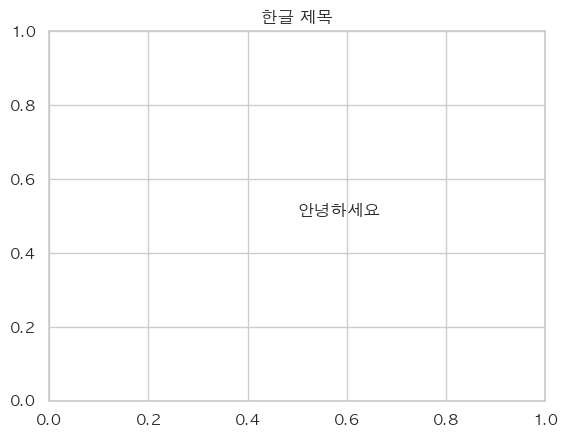

In [2]:
import matplotlib.font_manager as fm

font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf' # Replace with the actual path
font_properties = fm.FontProperties(fname=font_path)

plt.text(0.5, 0.5, '안녕하세요', fontproperties=font_properties)
plt.title('한글 제목', fontproperties=font_properties)
plt.show()


In [3]:
output_dataset = pd.read_excel('data/combined_scenario_data.xlsx')

print(output_dataset.head())

   Sector Code       Sector Name          2026           2027           2028  \
0          612               유연탄 -80108.418598 -146261.284150 -146261.284150   
1          622         천연가스(LNG) -15053.798323  -27485.099726  -27485.099726   
2          621                원유  -9365.185676  -17098.878086  -17098.878086   
3         1610              석탄제품  -4263.332424   -7783.956868   -7783.956868   
4         7300  장비·용품 및 지식재산권 임대  -3068.417533   -5602.291201   -5602.291201   

            2029           2030           2031           2032           2033  \
0 -172722.433048 -397016.370871 -397016.370871 -397016.370871 -522139.067111   
1  -32457.620790  -74606.445646  -74606.445646  -74606.445646  -98119.228294   
2  -20192.355363  -46413.748950  -46413.748950  -46413.748950  -61041.391126   
3   -9192.206788  -21129.024846  -21129.024846  -21129.024846  -27787.995991   
4   -6615.840771  -15207.040838  -15207.040838  -15207.040838  -19999.654169   

   ...           2041          2042   

In [4]:
# Excel 파일의 모든 시트 이름 확인
xl_file = pd.ExcelFile('data/combined_scenario_data.xlsx')
sheet_names = xl_file.sheet_names
print("Available sheets:")
for sheet in sheet_names:
    print(f"  - {sheet}")

# 1610이 포함되고 'indirect', 'import', 'value_added'가 포함된 시트 필터링
target_keywords = ['생산', '부가가치', '수입']
filtered_sheets = [sheet for sheet in sheet_names 
                   if '재생에너지' in sheet and any(keyword in sheet.lower() for keyword in target_keywords)]

print(f"\nFiltered sheets:")
for sheet in filtered_sheets:
    print(f"  - {sheet}")

Available sheets:
  - 석탄_수입유발
  - 재생에너지_수입유발
  - 재생에너지_취업유발
  - 석탄_취업유발
  - 재생에너지_고용유발
  - 석탄_고용유발
  - 재생에너지_부가가치유발
  - 석탄_부가가치유발
  - 재생에너지_생산유발
  - 석탄_생산유발

Filtered sheets:
  - 재생에너지_수입유발
  - 재생에너지_부가가치유발
  - 재생에너지_생산유발


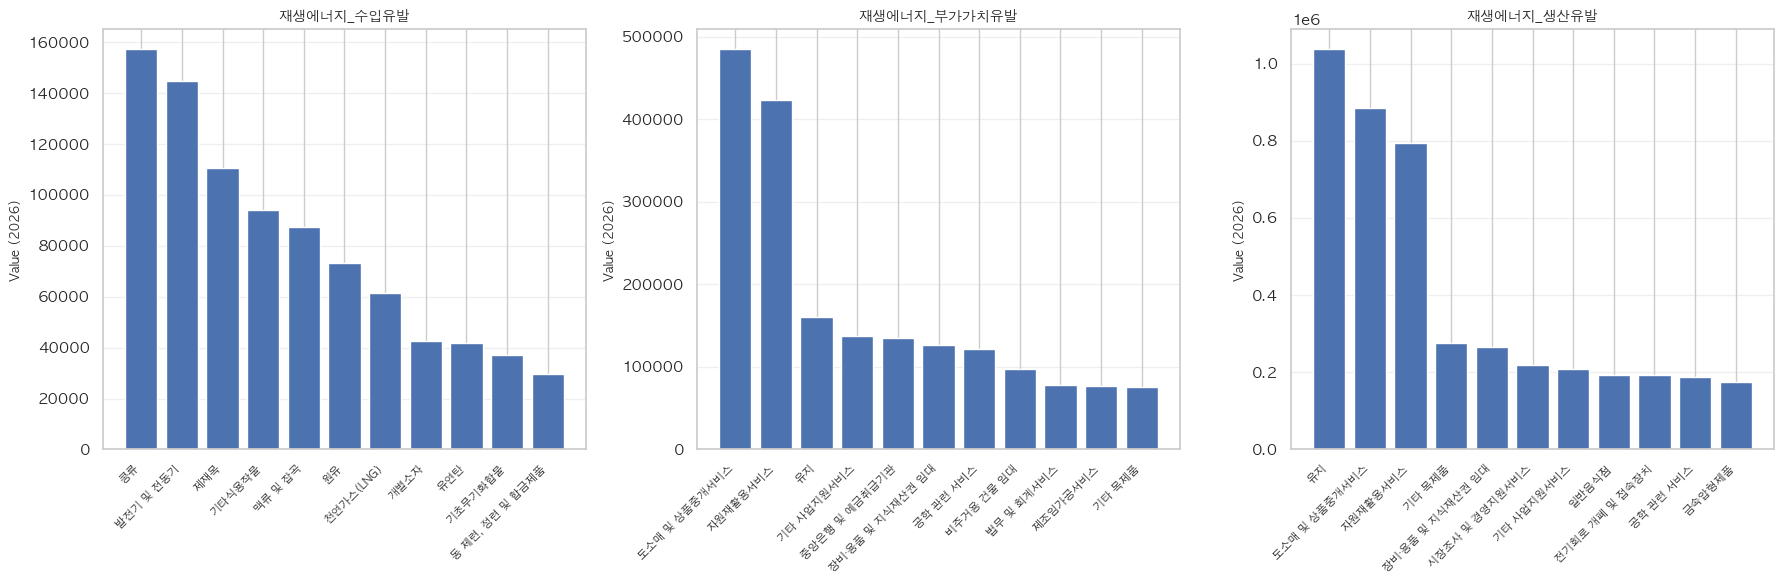

In [5]:
# 각 시트에서 2-12행, 2026년 열 데이터 추출 및 시각화
fig, axes = plt.subplots(1, len(filtered_sheets), figsize=(18, 6))

# 시트가 하나일 경우를 대비해 axes를 리스트로 변환
if len(filtered_sheets) == 1:
    axes = [axes]

for idx, sheet_name in enumerate(filtered_sheets):
    # 데이터 읽기
    df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)
    
    # 2-12행 (인덱스 1-11), 2026년 열 추출
    data_subset = df.iloc[1:12]
    sector_names = data_subset['Sector Name'].values
    values_2026 = data_subset['2026'].values
    
    # Column chart 그리기
    axes[idx].bar(range(len(values_2026)), values_2026)
    axes[idx].set_xticks(range(len(sector_names)))
    axes[idx].set_xticklabels(sector_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(sheet_name, fontsize=10)
    axes[idx].set_ylabel('Value (2026)', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/aggregated_4506_charts_economics.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Excel 파일의 모든 시트 이름 확인
xl_file = pd.ExcelFile('data/combined_scenario_data.xlsx')
sheet_names = xl_file.sheet_names
print("Available sheets:")
for sheet in sheet_names:
    print(f"  - {sheet}")

# 1610이 포함되고 'indirect', 'import', 'value_added'가 포함된 시트 필터링
target_keywords = ['고용', '취업']
filtered_sheets = [sheet for sheet in sheet_names 
                   if '재생에너지' in sheet and any(keyword in sheet.lower() for keyword in target_keywords)]

print(f"\nFiltered sheets:")
for sheet in filtered_sheets:
    print(f"  - {sheet}")

Available sheets:
  - 석탄_수입유발
  - 재생에너지_수입유발
  - 재생에너지_취업유발
  - 석탄_취업유발
  - 재생에너지_고용유발
  - 석탄_고용유발
  - 재생에너지_부가가치유발
  - 석탄_부가가치유발
  - 재생에너지_생산유발
  - 석탄_생산유발

Filtered sheets:
  - 재생에너지_취업유발
  - 재생에너지_고용유발


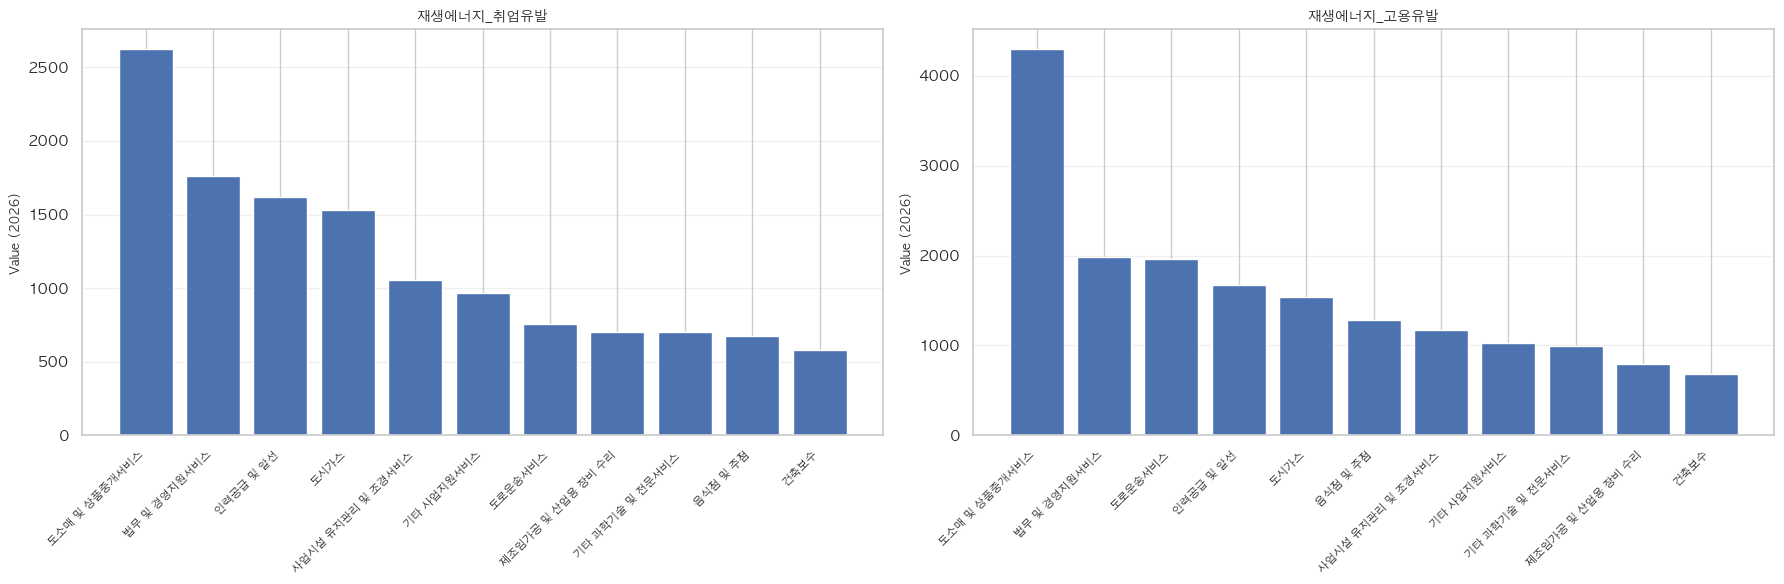

In [7]:
# 각 시트에서 2-12행, 2026년 열 데이터 추출 및 시각화
fig, axes = plt.subplots(1, len(filtered_sheets), figsize=(18, 6))

# 시트가 하나일 경우를 대비해 axes를 리스트로 변환
if len(filtered_sheets) == 1:
    axes = [axes]

for idx, sheet_name in enumerate(filtered_sheets):
    # 데이터 읽기
    df = pd.read_excel('data/combined_scenario_data.xlsx', sheet_name=sheet_name)
    
    # 2-12행 (인덱스 1-11), 2026년 열 추출
    data_subset = df.iloc[1:12]
    sector_names = data_subset['Sector Name'].values
    values_2026 = data_subset['2026'].values
    
    # Column chart 그리기
    axes[idx].bar(range(len(values_2026)), values_2026)
    axes[idx].set_xticks(range(len(sector_names)))
    axes[idx].set_xticklabels(sector_names, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(sheet_name, fontsize=10)
    axes[idx].set_ylabel('Value (2026)', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/aggregated_4506_charts_job.png', dpi=300, bbox_inches='tight')
plt.show()